In [ ]:
# ===============================================
# STEP 1: Import Required Libraries
# ===============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings, os, zipfile
warnings.filterwarnings('ignore')


In [ ]:
# ===============================================
# STEP 2: Mount Drive and Load Dataset (ZIP)
# ===============================================
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/ML-datasets/Credit_Score_Classification.zip"   # ✅ update if needed
UNZIP_DIR = "/content/data_credit"

# Unzip file
if not os.path.exists(UNZIP_DIR):
    os.makedirs(UNZIP_DIR)

with zipfile.ZipFile(DRIVE_PATH, 'r') as zip_ref:
    zip_ref.extractall(UNZIP_DIR)

# Find CSV inside ZIP and load
for file in os.listdir(UNZIP_DIR):
    if file.endswith(".csv"):
        csv_path = os.path.join(UNZIP_DIR, file)
        print("Found CSV file:", csv_path)
        df = pd.read_csv(csv_path)
        break

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found CSV file: /content/data_credit/train.csv


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
# ===============================================
# STEP 3: Explore Dataset
# ===============================================
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
df.info()


Shape: (100000, 28)

Columns:
 Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

Missing values:
 ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card  

In [ ]:
# ===============================================
# STEP 4: Data Cleaning and Type Conversion
# ===============================================
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 🔹 Drop columns that are identifiers or useless for modeling
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
df = df.drop(columns=drop_cols, errors='ignore')

# 🔹 Replace symbols like '_' or 'NA' or 'nan' with proper NaN
df.replace(['_', 'NA', 'na', 'NaN', 'nan', 'Null', '-'], np.nan, inplace=True)

# 🔹 Convert numeric-looking columns to numeric type safely
num_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 🔹 Handle 'Credit_History_Age' like '22 Years and 3 Months' → numeric months
def convert_credit_age(x):
    try:
        years = int(str(x).split(' ')[0])
        months = int(str(x).split(' ')[3])
        return years * 12 + months
    except:
        return np.nan

df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_credit_age)

# 🔹 Fill numeric missing values with median
df[num_cols + ['Credit_History_Age']] = df[num_cols + ['Credit_History_Age']].fillna(
    df[num_cols + ['Credit_History_Age']].median()
)

# 🔹 Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 🔹 Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Cleaned DataFrame:")
df.info()
df.head()


✅ Cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  int64  
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     100000 non-null  float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  float64
 8   Type_of_Loan              100000 non-null  int64  
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    100000 non-null  float64
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  float64
 13  Credit_Mix              

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.0,12,19114.12,1824.843333,3,4,3,4.0,128,3,...,2,809.98,26.822620,265.0,1,49.574949,80.415295,3,312.494089,0
1,23.0,12,19114.12,3093.745000,3,4,3,4.0,128,-1,...,1,809.98,31.944960,219.0,1,49.574949,118.280222,4,284.629162,0
2,-500.0,12,19114.12,3093.745000,3,4,3,4.0,128,3,...,1,809.98,28.609352,267.0,1,49.574949,81.699521,5,331.209863,0
3,23.0,12,19114.12,3093.745000,3,4,3,4.0,128,5,...,1,809.98,31.377862,268.0,1,49.574949,199.458074,6,223.451310,0
4,23.0,12,19114.12,1824.843333,3,4,3,4.0,128,6,...,1,809.98,24.797347,269.0,1,49.574949,41.420153,2,341.489231,0


In [ ]:
# ===============================================
# STEP 5: Split Features and Target
# ===============================================
target_col = 'Credit_Score'  # 🎯 Target column is Credit_Score (Good / Standard / Poor)

# Encode target labels
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col])

X = df.drop(columns=[target_col])
y = df[target_col]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)


Train shape: (80000, 22)  | Test shape: (20000, 22)


In [ ]:
# ===============================================
# STEP 6: Feature Scaling
# ===============================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# ===============================================
# STEP 7: Impute Missing Values and Train Models
# ===============================================

# 🔹 Handle missing values for numerical columns
num_imputer = SimpleImputer(strategy='mean')
X_train_imputed = num_imputer.fit_transform(X_train_scaled)
X_test_imputed = num_imputer.transform(X_test_scaled)

# 🔹 Define models (only required ones)
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 🔹 Train and Evaluate
for name, model in models.items():
    print(f"\n🔹 {name}")
    model.fit(X_train_imputed, y_train)
    y_pred = model.predict(X_test_imputed)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



🔹 Logistic Regression
Accuracy: 0.6123
              precision    recall  f1-score   support

           0       0.52      0.39      0.45      3566
           1       0.64      0.44      0.52      5799
           2       0.62      0.78      0.69     10635

    accuracy                           0.61     20000
   macro avg       0.60      0.54      0.55     20000
weighted avg       0.61      0.61      0.60     20000


🔹 Decision Tree
Accuracy: 0.6857
              precision    recall  f1-score   support

           0       0.58      0.60      0.59      3566
           1       0.68      0.68      0.68      5799
           2       0.72      0.72      0.72     10635

    accuracy                           0.69     20000
   macro avg       0.66      0.67      0.66     20000
weighted avg       0.69      0.69      0.69     20000


🔹 Random Forest
Accuracy: 0.78795
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      3566
           1       0

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# ===============================================
# STEP 7: Impute Missing Values and Train Models
# ===============================================

# 🔹 Handle missing values for numerical columns
num_imputer = SimpleImputer(strategy='mean')
X_train_imputed = num_imputer.fit_transform(X_train_scaled)
X_test_imputed = num_imputer.transform(X_test_scaled)

# 🔹 Define models (only required ones)
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 🔹 Train, Evaluate, and Store results
results = []

for name, model in models.items():
    print(f"\n🔹 {name}")
    model.fit(X_train_imputed, y_train)
    y_pred = model.predict(X_test_imputed)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred))



🔹 Logistic Regression
Accuracy: 0.6123
              precision    recall  f1-score   support

           0       0.52      0.39      0.45      3566
           1       0.64      0.44      0.52      5799
           2       0.62      0.78      0.69     10635

    accuracy                           0.61     20000
   macro avg       0.60      0.54      0.55     20000
weighted avg       0.61      0.61      0.60     20000


🔹 Decision Tree
Accuracy: 0.6857
              precision    recall  f1-score   support

           0       0.58      0.60      0.59      3566
           1       0.68      0.68      0.68      5799
           2       0.72      0.72      0.72     10635

    accuracy                           0.69     20000
   macro avg       0.66      0.67      0.66     20000
weighted avg       0.69      0.69      0.69     20000


🔹 Random Forest
Accuracy: 0.788
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      3566
           1       0.7


📊 Model Performance Summary:
                 Model  Accuracy  Precision   Recall  F1-Score
0  Logistic Regression   0.61230   0.609984  0.61230  0.598855
1        Decision Tree   0.68570   0.686357  0.68570  0.686002
2        Random Forest   0.78795   0.787699  0.78795  0.787768


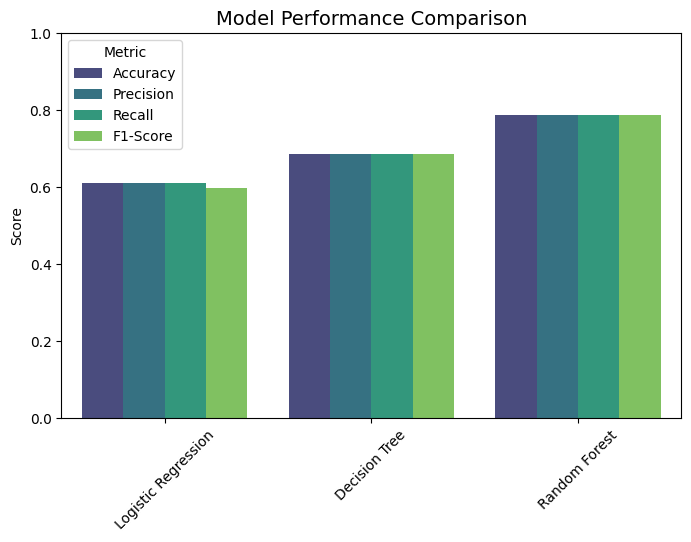

In [ ]:
# ===============================================
# STEP 8: Compare Model Performance
# ===============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print("\n📊 Model Performance Summary:")
print(results_df)

# Plot comparison
plt.figure(figsize=(8,5))
sns.barplot(
    data=results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-Score"]),
    x="Model", y="value", hue="variable", palette="viridis"
)
plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()



📈 Model Performance (with ROC-AUC):
                 Model  Accuracy  Precision   Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.61230   0.609984  0.61230  0.598855  0.773367
1        Decision Tree   0.68570   0.686357  0.68570  0.686002  0.743775
2        Random Forest   0.78795   0.787699  0.78795  0.787768  0.910234

✅ Best Model based on ROC-AUC: Random Forest


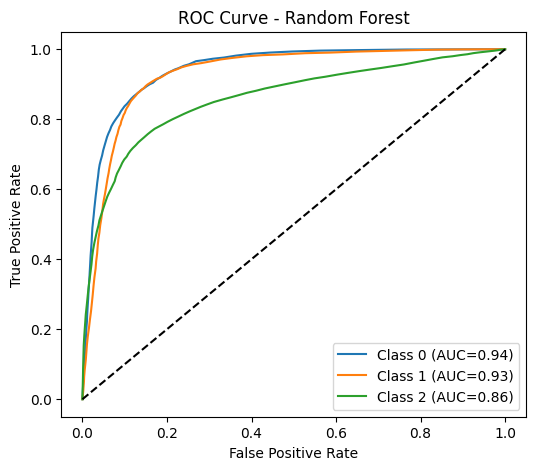

In [ ]:
# ===============================================
# STEP 9: ROC Curve for the Best Model
# ===============================================
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

# Recalculate ROC-AUC for each model (if not already stored)
roc_auc_scores = []

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_imputed)
        # Handle multi-class AUC
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    else:
        # Some models (like SVM without probability=True) won't have predict_proba
        auc = None
    roc_auc_scores.append(auc)

# Add ROC-AUC to results dataframe
results_df["ROC-AUC"] = roc_auc_scores

# Display updated table
print("\n📈 Model Performance (with ROC-AUC):")
print(results_df)

# Identify best model based on ROC-AUC
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0, 0]
print(f"\n✅ Best Model based on ROC-AUC: {best_model_name}")

# Plot ROC curve for the best model
best_model = models[best_model_name]
y_prob = best_model.predict_proba(X_test_imputed)

# Handle multi-class ROC curves
if len(set(y_test)) > 2:
    plt.figure(figsize=(6,5))
    for i in range(y_prob.shape[1]):
        fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
        auc_score = roc_auc_score(y_test == i, y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc_score:.2f})")
else:
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    auc_score = roc_auc_score(y_test, y_prob[:, 1])
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={auc_score:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()
